# Single-Engine GRU with Bayesian SGLD Uncertainty & Adaptive Dual-Engine Execution

**System Architecture & Pipeline Overview:**
This notebook builds and tests an institutional-grade, end-to-end algorithmic trading engine. It moves from raw data ingestion to Bayesian neural network training, dynamic threshold calibration, and finally, a zero-lookahead pyramiding backtest[cite: 6].

**Key Components:**
1. **Data:** 19D continuous feature engineering with prominence-based swing labeling[cite: 6].
2. **Model:** Direct-projected GRU with internal `LayerNorm` and Auto-calibrated focal loss[cite: 6].
3. **Training:** 100-snapshot MCMC posterior sampling via SGLD[cite: 6].
4. **Calibration:** 5-parameter CUDA-optimized dual-pathway signal gating[cite: 6].
5. **Execution:** Next-bar Open fills, volatility-gated staged pyramiding, and HTML5 transparency dashboards[cite: 6].

## 1. Setup & Imports

**What this cell does:**
* Installs required quantitative and financial libraries (`TA-Lib`, `mplfinance`, `quantstats`, etc.)[cite: 6].
* Imports standard data processing and PyTorch deep learning modules[cite: 6].
* Configures the hardware device to use GPU (`cuda`) if available[cite: 6].
* Mounts Google Drive to enable automated exporting of model checkpoints, charts, and HTML apps later in the pipeline[cite: 6].

In [83]:
!pip install -q TA-Lib mplfinance seaborn scikit-learn yfinance quantstats

import math
import copy
import os
import warnings
import json
import numpy as np
import pandas as pd
import yfinance as yf
import talib
from scipy.signal import find_peaks
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
import quantstats as qs
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import mplfinance as mpf

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")

try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
except ImportError:
    pass

Using compute device: cuda


## 2. Data Pipeline with Outlier Clipping

**What this cell does:**
* Defines the `DataPipeline` class responsible for fetching Yahoo Finance data and computing 19 causal technical indicators (RSI, Stochastics, Volume Z-Scores, MA Curvature)[cite: 6].
* Implements a local peak/trough detection algorithm (`find_peaks`) to mathematically label $2.5\%$ price swings as Ground Truth Regimes (0 = Trough/Buy, 1 = Peak/Sell)[cite: 6].
* Slices the data into `train`, `val`, and `test` sets, fitting a `StandardScaler` **strictly** on the training set to prevent future data leakage during normalization[cite: 6].

In [84]:
class DataPipeline:
    def __init__(self, ticker="^HSI", start_date="2010-07-01", end_date="2026-07-01", time_steps=5):
        self.ticker = ticker
        self.start_date = pd.to_datetime(start_date) - pd.Timedelta(days=180)
        self.end_date = end_date
        self.time_steps = time_steps

        # 19-Dimensional Continuous Input Vector
        self.feature_columns = [
            'RSI_100_Ctr', 'RSI_10_Ctr', 'FastK_10_Ctr', 'FastK_100_Ctr',
            'RSI_100_Diff20', 'FastK_100_Diff20',
            'Vol_1D_Z20', 'Vol_5D_Sum_Z100',
            'Ret_1D', 'Prc_Dev_5D', 'Prc_Dev_20D', 'Prc_Dev_100D',
            'MA_Curvature_Kappa',
            'RSI_Spread_10_100', 'FastK_Spread_10_100', 'Stoch_KD_Diff_10', 'RSI_Div_20D',
            'Prc_Dev_20D_Accel', 'MA_Ribbon_Spread'
        ]

    def add_features(self, df):
        sma_5 = talib.SMA(df['Close'], timeperiod=5)
        sma_20 = talib.SMA(df['Close'], timeperiod=20)
        sma_100 = talib.SMA(df['Close'], timeperiod=100)

        rsi_100 = talib.RSI(df['Close'], timeperiod=100) / 100.0 - 0.5
        rsi_10  = talib.RSI(df['Close'], timeperiod=10) / 100.0 - 0.5

        fastk_10, fastd_10 = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=10, fastd_period=3, fastd_matype=0)
        fastk_10_ctr = fastk_10 / 100.0 - 0.5
        fastd_10_ctr = fastd_10 / 100.0 - 0.5

        fastk_100, _ = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=100, fastd_period=5, fastd_matype=0)
        fastk_100_ctr = fastk_100 / 100.0 - 0.5

        df['RSI_100_Ctr']   = rsi_100
        df['RSI_10_Ctr']    = rsi_10
        df['FastK_10_Ctr']  = fastk_10_ctr
        df['FastK_100_Ctr'] = fastk_100_ctr

        df['RSI_100_Diff20']   = df['RSI_100_Ctr'].diff(20)
        df['FastK_100_Diff20'] = df['FastK_100_Ctr'].diff(20)

        df['RSI_Spread_10_100']   = df['RSI_10_Ctr'] - df['RSI_100_Ctr']
        df['FastK_Spread_10_100'] = df['FastK_10_Ctr'] - df['FastK_100_Ctr']
        df['Stoch_KD_Diff_10']    = fastk_10_ctr - fastd_10_ctr

        # Only divergence has natural [-1, 1] clipping (identical to old code)
        ret_20d = df['Close'].pct_change(20).fillna(0)
        rsi_diff_20d = df['RSI_10_Ctr'].diff(20).fillna(0)
        df['RSI_Div_20D'] = (rsi_diff_20d - ret_20d).clip(-1.0, 1.0)

        # Raw volume Z-scores (unclipped to allow exhaustion spikes)
        vol_mean_20 = df['Volume'].rolling(window=20).mean()
        vol_std_20  = df['Volume'].rolling(window=20).std().replace(0, np.nan)
        df['Vol_1D_Z20'] = ((df['Volume'] - vol_mean_20) / vol_std_20).fillna(0)

        vol_sum_5          = df['Volume'].rolling(window=5).sum()
        vol_sum_5_mean_100 = vol_sum_5.rolling(window=100).mean()
        vol_sum_5_std_100  = vol_sum_5.rolling(window=100).std().replace(0, np.nan)
        df['Vol_5D_Sum_Z100'] = ((vol_sum_5 - vol_sum_5_mean_100) / vol_sum_5_std_100).fillna(0)

        # Raw returns and moving average stretches (unclipped)
        df['Ret_1D']       = df['Close'].pct_change()
        df['Prc_Dev_5D']   = (df['Close'] / sma_5) - 1.0
        df['Prc_Dev_20D']  = (df['Close'] / sma_20) - 1.0
        df['Prc_Dev_100D'] = (df['Close'] / sma_100) - 1.0

        df['Prc_Dev_20D_Accel'] = df['Prc_Dev_20D'].diff(1).diff(1).fillna(0)
        df['MA_Ribbon_Spread']  = (df['Prc_Dev_5D'] - df['Prc_Dev_20D']) - (df['Prc_Dev_20D'] - df['Prc_Dev_100D'])

        # Geometric curvature (unclipped)
        y1 = df['Close'] / sma_100.replace(0, np.nan)
        y2 = sma_20 / sma_100.replace(0, np.nan)
        y3 = 1.0
        x1, x2, x3 = 0.0, 20.0, 100.0

        side_a = np.sqrt((x2 - x3)**2 + (y2 - y3)**2)
        side_b = np.sqrt((x1 - x3)**2 + (y1 - y3)**2)
        side_c = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

        signed_area_2x = (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))
        denom = (side_a * side_b * side_c).replace(0, np.nan)
        df['MA_Curvature_Kappa'] = (2.0 * signed_area_2x / denom).fillna(0)

        df['5D_MA']   = sma_5
        df['20D_MA']  = sma_20
        df['100D_MA'] = sma_100

        return df.replace([np.inf, -np.inf], 0).fillna(0)

    def add_labels(self, df, minor_pct=0.025, min_dist=1):
        log_prices = np.log(df['Close'].values)
        peaks, _   = find_peaks(log_prices, distance=min_dist, prominence=minor_pct)
        troughs, _ = find_peaks(-log_prices, distance=min_dist, prominence=minor_pct)
        labels = np.full(len(log_prices), 2)
        for p in peaks:   labels[p] = 1
        for t in troughs: labels[t] = 0
        df['Regime'] = labels
        return df.dropna()

    def prepare_data(self, val_days=504, test_days=1008):
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        df = df.loc[:, ~df.columns.duplicated()]

        df = self.add_features(df)
        df = self.add_labels(df)

        features = df[self.feature_columns].values
        labels = df['Regime'].values

        X, Y = [], []
        for i in range(len(features) - self.time_steps + 1):
            X.append(features[i:(i + self.time_steps)])
            Y.append(labels[i + self.time_steps - 1])

        X, Y = np.array(X), np.array(Y, dtype=np.int64)

        test_idx = len(X) - test_days
        val_idx = test_idx - val_days

        X_train, X_val, X_test = X[:val_idx], X[val_idx:test_idx], X[test_idx:]
        Y_train, Y_val, Y_test = Y[:val_idx], Y[val_idx:test_idx], Y[test_idx:]

        scaler = StandardScaler()
        B, T, F_dim = X_train.shape
        X_train_reshaped = X_train.reshape(-1, F_dim)
        scaler.fit(X_train_reshaped)

        return {
            'X_train': scaler.transform(X_train_reshaped).reshape(B, T, F_dim),
            'X_val': scaler.transform(X_val.reshape(-1, F_dim)).reshape(X_val.shape[0], T, F_dim),
            'X_test': scaler.transform(X_test.reshape(-1, F_dim)).reshape(X_test.shape[0], T, F_dim),
            'Y_train': Y_train, 'Y_val': Y_val, 'Y_test': Y_test,
            'clean_df': df.iloc[-len(X):].copy(),
            'scaler': scaler
        }

## 3. Data Execution & Label Verification Plot

**What this cell does:**
* Instantiates the `DataPipeline` for the target ticker (e.g., `^HSI`) over the specified date range[cite: 6].
* Processes the dataset into 3D tensor shapes `(Batch, Time_Steps, Features)` required by the GRU[cite: 6].
* Generates a scatter plot of the historical prices overlaid with Green Triangles (Ground Truth Buys) and Red Triangles (Ground Truth Sells) so you can visually verify the accuracy of the labeling algorithm[cite: 6].

⚡ Preparing Data Pipeline for ^HSI (Lookback=5)...

✅ Data Pipeline Ready:
 • Input Feature Dimension : 19D
 • X_train Shape           : (2080, 5, 19)
 • X_val Shape             : (252, 5, 19)
 • X_test Shape            : (252, 5, 19)


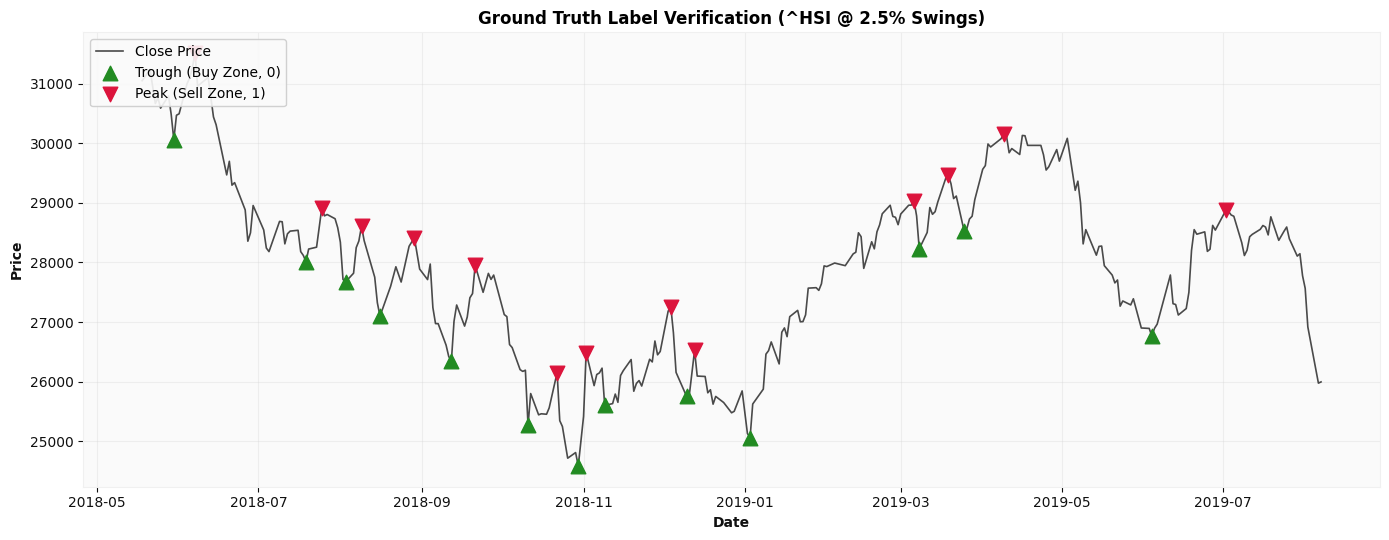

In [85]:
TARGET_TICKER = "^HSI"
START_DATE = "2010-01-01"
END_DATE = "2020-01-01"
VAL_DAYS_N = 252
TEST_DAYS_N = 252
TIME_STEPS = 5

print(f"⚡ Preparing Data Pipeline for {TARGET_TICKER} (Lookback={TIME_STEPS})...")
pipeline = DataPipeline(
    ticker=TARGET_TICKER,
    start_date=START_DATE,
    end_date=END_DATE,
    time_steps=TIME_STEPS
)

dataset = pipeline.prepare_data(val_days=VAL_DAYS_N, test_days=TEST_DAYS_N)
clean_df = dataset['clean_df']
INPUT_DIM = len(pipeline.feature_columns)

print("\n✅ Data Pipeline Ready:")
print(f" • Input Feature Dimension : {INPUT_DIM}D")
print(f" • X_train Shape           : {dataset['X_train'].shape}")
print(f" • X_val Shape             : {dataset['X_val'].shape}")
print(f" • X_test Shape            : {dataset['X_test'].shape}")

def plot_labels(df, start_idx=-400, end_idx=-100):
    plot_df = df.iloc[start_idx:end_idx].copy()
    plt.figure(figsize=(14, 5.5))
    plt.plot(plot_df.index, plot_df['Close'], label='Close Price', color='black', alpha=0.7, lw=1.2)

    troughs = plot_df[plot_df['Regime'] == 0]
    plt.scatter(troughs.index, troughs['Close'], color='forestgreen', marker='^', s=110, label='Trough (Buy Zone, 0)', zorder=5)

    peaks = plot_df[plot_df['Regime'] == 1]
    plt.scatter(peaks.index, peaks['Close'], color='crimson', marker='v', s=110, label='Peak (Sell Zone, 1)', zorder=5)

    plt.title(f'Ground Truth Label Verification ({TARGET_TICKER} @ 2.5% Swings)', fontsize=12, fontweight='bold')
    plt.xlabel('Date', fontweight='bold')
    plt.ylabel('Price', fontweight='bold')
    plt.legend(loc='upper left', framealpha=0.9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_labels(clean_df, start_idx=-400, end_idx=-100)

## 4. Deep Learning Architecture

**What this cell does:**
* Constructs the `RegimeGRU` neural network: It projects the 19D input into a 12D space using a Linear layer and LeakyReLU, normalizes it, and feeds it into an 8D GRU followed by a final classification head[cite: 6].
* Defines the `AutoCBLoss` (Auto-Calibrated Class-Balanced Loss): A custom loss function that dynamically penalizes false positives and false negatives based on the heavy class imbalance between neutral bars and rare turning points[cite: 6].

In [86]:
class RegimeGRU(nn.Module):
    def __init__(self, input_features=19, proj_dim=12, hidden_dim=8, output_classes=1, negative_slope=0.05):
        super().__init__()
        self.input_features = input_features
        self.proj_dim = proj_dim
        self.hidden_dim = hidden_dim

        self.input_projector = nn.Sequential(
            nn.Linear(input_features, proj_dim),
            nn.LeakyReLU(negative_slope=negative_slope),
            nn.LayerNorm(proj_dim)
        )

        self.gru = nn.GRU(
            input_size=proj_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.hidden_norm = nn.LayerNorm(hidden_dim, elementwise_affine=True)
        self.fc = nn.Linear(hidden_dim, output_classes)

    def get_hidden_state(self, x):
        z = self.input_projector(x)
        out, _ = self.gru(z)
        h_raw = out[:, -1, :]
        return self.hidden_norm(h_raw)

    def forward(self, x):
        final_state = self.get_hidden_state(x)
        logits = self.fc(final_state).squeeze(-1)
        return logits, final_state


class AutoCBLoss(nn.Module):
    def __init__(self, beta=0.999, gamma_pos=0.0, gamma_neg=1.5, margin=0.05, eps=1e-7):
        super().__init__()
        self.beta = beta
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.margin = margin
        self.eps = eps

    def forward(self, logits, targets):
        n_pos = torch.clamp(targets.sum(), min=1.0)
        n_neg = torch.clamp((1.0 - targets).sum(), min=1.0)

        eff_pos = (1.0 - (self.beta ** n_pos)) / (1.0 - self.beta)
        eff_neg = (1.0 - (self.beta ** n_neg)) / (1.0 - self.beta)
        alpha_pos = eff_neg / eff_pos

        p = torch.sigmoid(logits)
        p = torch.clamp(p, min=self.eps, max=1.0 - self.eps)

        loss_pos = -alpha_pos * targets * ((1.0 - p) ** self.gamma_pos) * torch.log(p)
        p_shifted = torch.clamp(p - self.margin, min=0.0)
        loss_neg = -(1.0 - targets) * (p_shifted ** self.gamma_neg) * torch.log(1.0 - p)

        return (loss_pos + loss_neg).mean()

## 5. Bayesian SGLD Training Engine

**What this cell does:**
* Implements Stochastic Gradient Langevin Dynamics (SGLD) to capture model uncertainty rather than just a single point estimate[cite: 6].
* **Phase 1 (Adam):** Rapidly fits the model to the training data until a target loss is achieved[cite: 6].
* **Phase 2 (SGD Warmup):** Transitions the optimizer and injects scaled Gaussian noise to bump the model out of local minima[cite: 6].
* **Phase 3 (MCMC Sampling):** Explores the posterior loss landscape, saving the model's weights every few steps to collect an ensemble of 100 "expert" snapshots[cite: 6].

In [87]:
def train_sgld(
    model,
    X_train,
    Y_train,
    min_fit_epochs=200,
    max_fit_epochs=1000,
    target_loss=0.30,
    transition_epochs=100,
    snapshot_step=5,
    n_snapshots=100,
    lr_adam=1e-3,
    lr_sgd=5e-5,
    noise_multiplier=0.006,
    weight_decay=1e-3,
    batch_size=32,
    verbose=True
):
    Y_train_bin = (Y_train != 2).astype(np.float32) if np.max(Y_train) > 1 else Y_train.astype(np.float32)

    X_cuda = torch.tensor(X_train, dtype=torch.float32, device=DEVICE)
    Y_cuda = torch.tensor(Y_train_bin, dtype=torch.float32, device=DEVICE)
    N = X_cuda.size(0)

    n_pos = np.sum(Y_train_bin == 1.0)
    pi = max(1e-4, float(n_pos / max(1.0, N)))
    with torch.no_grad():
        model.fc.bias.fill_(math.log(pi / (1.0 - pi)))

    criterion = AutoCBLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    experts = []

    # Phase 1: Pure Fitting (Adam)
    optimizer_adam = torch.optim.Adam(trainable_params, lr=lr_adam, weight_decay=weight_decay)
    model.train()
    for epoch in range(max_fit_epochs):
        epoch_loss, n_b = 0.0, 0
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            bx, by = X_cuda[idx], Y_cuda[idx]
            optimizer_adam.zero_grad(set_to_none=True)
            logits, _ = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer_adam.step()
            epoch_loss += loss.item()
            n_b += 1

        avg_loss = epoch_loss / n_b
        if verbose and ((epoch + 1) % 50 == 0 or (epoch + 1) == max_fit_epochs):
            print(f"   [Phase 1 Adam]       Epoch {epoch+1:4d}/{max_fit_epochs} | Auto-CB Loss: {avg_loss:.4f}")

        if epoch >= min_fit_epochs and avg_loss <= target_loss:
            if verbose:
                print(f"   [Phase 1 Adam]       Target loss ({target_loss}) reached at epoch {epoch+1}. Moving to Phase 2.")
            break

    # Phase 2: Transition (SGD + Noise Warmup)
    optimizer_sgd = torch.optim.SGD(trainable_params, lr=lr_sgd, weight_decay=weight_decay)
    for epoch in range(transition_epochs):
        warmup_factor = float(epoch + 1) / float(transition_epochs)
        current_noise_std = math.sqrt(2.0 * lr_sgd) * (noise_multiplier * warmup_factor)
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            bx, by = X_cuda[idx], Y_cuda[idx]
            optimizer_sgd.zero_grad(set_to_none=True)
            logits, _ = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer_sgd.step()
            with torch.no_grad():
                for p in trainable_params:
                    p.add_(torch.randn_like(p) * current_noise_std)

        if verbose and ((epoch + 1) % 50 == 0 or (epoch + 1) == transition_epochs):
            print(f"   [Phase 2 Transition] Epoch {epoch+1:3d}/{transition_epochs} (Warmup: {warmup_factor*100:.0f}%)")

    # Phase 3: SGLD Snapshot Sampling
    full_noise_std = math.sqrt(2.0 * lr_sgd) * noise_multiplier
    snapshot_epochs = n_snapshots * snapshot_step
    for epoch in range(1, snapshot_epochs + 1):
        perm = torch.randperm(N, device=DEVICE)
        for i in range(0, N, batch_size):
            idx = perm[i:i + batch_size]
            bx, by = X_cuda[idx], Y_cuda[idx]
            optimizer_sgd.zero_grad(set_to_none=True)
            logits, _ = model(bx)
            loss = criterion(logits, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer_sgd.step()
            with torch.no_grad():
                for p in trainable_params:
                    p.add_(torch.randn_like(p) * full_noise_std)

        if epoch % snapshot_step == 0:
            experts.append(copy.deepcopy(model.state_dict()))

    model.eval()
    print(f"✅ SGLD Sampling Complete: Collected {len(experts)} posterior snapshot experts.\n")
    return experts

## 6. Training Execution & Dilated Confusion Matrix

**What this cell does:**
* Checks Google Drive for an existing model checkpoint to save time; if none exists, it triggers the SGLD training loop and saves the resulting 100 experts[cite: 6].
* Runs the validation set through all 100 experts to generate a mean probability score $P(t)$ for each bar[cite: 6].
* Evaluates the model using a **Dilated Confusion Matrix**, allowing a $\pm 1$ bar tolerance window to calculate realistic Event Recall, Active Signal Precision, and False Alarm Rates[cite: 6].

📦 Found existing checkpoint: /content/drive/MyDrive/EDE Engines/GRU_Engine_^HSI_20100101_20200101.pt
⚡ Skipping training and reloading model state + Bayesian experts...
✅ Successfully loaded 100 posterior snapshot experts.

🎯 Calibration Metrics (±1 Bar Window @ θ=0.30):
 • Event Recall (Pivots Caught) : 18 / 29 (62.1%)
 • Active Signal Precision      : 27 / 78 (34.6%)
 • Pure Noise False Alarms      : 51 / 223 (22.9% FPR)



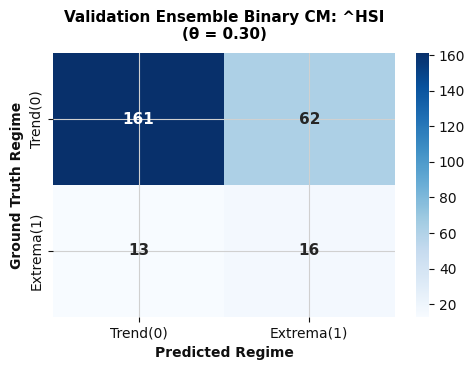

In [88]:
PROJ_DIM = 12
HIDDEN_DIM = 8

meta = {
    'ticker': TARGET_TICKER,
    'start_date': START_DATE,
    'end_date': END_DATE,
    'time_steps': TIME_STEPS,
    'feature_columns': pipeline.feature_columns,
    'proj_dim': PROJ_DIM,
    'hidden_dim': HIDDEN_DIM
}

# 1. Resolve Save Directory & Target File Path
save_dir = "/content/drive/MyDrive/EDE Engines" if os.path.exists('/content/drive') else "./checkpoints"
os.makedirs(save_dir, exist_ok=True)

start_clean = meta['start_date'].replace('-', '')
end_clean = meta['end_date'].replace('-', '')
ckpt_path = os.path.join(save_dir, f"GRU_Engine_{meta['ticker']}_{start_clean}_{end_clean}.pt")

# 2. Checkpoint Loading / Training Gate
if os.path.exists(ckpt_path):
    print(f"📦 Found existing checkpoint: {ckpt_path}")
    print(f"⚡ Skipping training and reloading model state + Bayesian experts...")

    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = RegimeGRU(
        input_features=len(ckpt['metadata']['feature_columns']),
        proj_dim=ckpt['metadata']['proj_dim'],
        hidden_dim=ckpt['metadata']['hidden_dim']
    ).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    experts = ckpt['experts']
    print(f"✅ Successfully loaded {len(experts)} posterior snapshot experts.\n")

else:
    print(f"🔍 No checkpoint found at: {ckpt_path}")
    print(f"▶ Initializing and training {TARGET_TICKER} Engine with SGLD Posterior Sampling...")

    model = RegimeGRU(
        input_features=INPUT_DIM,
        proj_dim=PROJ_DIM,
        hidden_dim=HIDDEN_DIM
    ).to(DEVICE)

    experts = train_sgld(
        model=model,
        X_train=dataset['X_train'],
        Y_train=dataset['Y_train'],
        min_fit_epochs=100,
        max_fit_epochs=150,
        target_loss=0.30,
        transition_epochs=50,
        snapshot_step=3,
        n_snapshots=100
    )

    # Save newly trained model checkpoint
    torch.save({
        'model_state_dict': model.state_dict(),
        'experts': experts,
        'scaler': dataset['scaler'],
        'metadata': meta
    }, ckpt_path)
    print(f"💾 Checkpoint saved to: {ckpt_path}\n")


# 3. Dilated Validation Evaluation
def eval_cm(model, experts, X_eval, Y_eval, threshold=0.30, window=1, title="Validation CM"):
    X_t = torch.tensor(X_eval, dtype=torch.float32, device=DEVICE)
    Y_bin = (Y_eval != 2).astype(np.int64) if np.max(Y_eval) > 1 else Y_eval.astype(np.int64)
    n_bars = len(Y_bin)

    model.eval()
    with torch.no_grad():
        states = []
        for s_dict in experts:
            model.load_state_dict(s_dict)
            states.append(model.get_hidden_state(X_t))

        H = torch.stack(states, dim=0)
        W = torch.stack([s['fc.weight'] for s in experts], dim=0)
        b = torch.stack([s['fc.bias'] for s in experts], dim=0).unsqueeze(-1)

        batched_logits = torch.bmm(H, W.transpose(1, 2)) + b
        probs = torch.sigmoid(batched_logits.squeeze(-1)).mean(dim=0).cpu().numpy()

    preds = (probs >= threshold).astype(int)

    # Event-Level Recall
    true_extrema_indices = np.where(Y_bin == 1)[0]
    total_extrema = len(true_extrema_indices)
    captured_extrema = 0

    for idx in true_extrema_indices:
        w_start = max(0, idx - window)
        w_end = min(n_bars, idx + window + 1)
        if np.any(preds[w_start:w_end] == 1):
            captured_extrema += 1

    recall = (captured_extrema / max(1, total_extrema)) * 100.0

    # Precision & False Alarm Rates
    pred_indices = np.where(preds == 1)[0]
    total_preds = len(pred_indices)
    valid_pred_bars = 0
    false_alarms = 0

    for idx in pred_indices:
        w_start = max(0, idx - window)
        w_end = min(n_bars, idx + window + 1)
        if np.any(Y_bin[w_start:w_end] == 1):
            valid_pred_bars += 1
        else:
            false_alarms += 1

    precision = (valid_pred_bars / max(1, total_preds)) * 100.0
    neutral_bars = np.sum(Y_bin == 0)
    fpr = (false_alarms / max(1, neutral_bars)) * 100.0

    print(f"🎯 Calibration Metrics (±{window} Bar Window @ θ={threshold:.2f}):")
    print(f" • Event Recall (Pivots Caught) : {captured_extrema} / {total_extrema} ({recall:.1f}%)")
    print(f" • Active Signal Precision      : {valid_pred_bars} / {total_preds} ({precision:.1f}%)")
    print(f" • Pure Noise False Alarms      : {false_alarms} / {neutral_bars} ({fpr:.1f}% FPR)\n")

    cm = confusion_matrix(Y_bin, preds, labels=[0, 1])
    plt.figure(figsize=(5.0, 3.8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=True,
        xticklabels=['Trend(0)', 'Extrema(1)'], yticklabels=['Trend(0)', 'Extrema(1)'],
        annot_kws={"size": 11, "weight": "bold"}
    )
    plt.title(f"{title}\n(θ = {threshold:.2f})", fontsize=11, fontweight='bold', pad=10)
    plt.xlabel("Predicted Regime", fontweight='bold')
    plt.ylabel("Ground Truth Regime", fontweight='bold')
    plt.tight_layout()
    plt.show()

    return probs

val_probs = eval_cm(
    model=model,
    experts=experts,
    X_eval=dataset['X_val'],
    Y_eval=dataset['Y_val'],
    threshold=0.30,
    title=f"Validation Ensemble Binary CM: {TARGET_TICKER}"
)

## 7. Dual-Engine EWMZ Calibration & Classification (5-Parameter CUDA Search)

**What this cell does:**
* Extracts the Epistemic Uncertainty $U(t)$ by measuring the variance between the top 10% and bottom 10% of the Bayesian expert predictions[cite: 6].
* Defines the `DualEWMZClassifierEngine` which generates trade signals based on two pathways[cite: 6]:
  * **Pathway A (Consensus):** High model probability AND low uncertainty[cite: 6].
  * **Pathway B (Epistemic Shock):** Sudden spike in uncertainty indicating a regime divergence[cite: 6].
* Causally computes dynamic Exponentially Weighted Moving Z-Score (EWMZ) thresholds so signals adapt to changing market volatility[cite: 6].

In [89]:
def extract_posterior(model, experts, X_eval):
    X_t = torch.tensor(X_eval, dtype=torch.float32, device=DEVICE)
    model.eval()
    with torch.no_grad():
        states = []
        for s_dict in experts:
            model.load_state_dict(s_dict)
            states.append(model.get_hidden_state(X_t))

        H = torch.stack(states, dim=0)
        W = torch.stack([s['fc.weight'] for s in experts], dim=0)
        b = torch.stack([s['fc.bias'] for s in experts], dim=0).unsqueeze(-1)

        batched_logits = torch.bmm(H, W.transpose(1, 2)) + b
        probs_tensor = torch.sigmoid(batched_logits.squeeze(-1)).transpose(0, 1)  # (N, S)

        p_mean = probs_tensor.mean(dim=1).cpu().numpy()

        tail_count = max(1, int(probs_tensor.size(1) * 0.10))
        top_vals, _ = torch.topk(probs_tensor, tail_count, dim=1, largest=True)
        bot_vals, _ = torch.topk(probs_tensor, tail_count, dim=1, largest=False)

        p_upper = top_vals.mean(dim=1)
        p_lower = bot_vals.mean(dim=1)
        unc_epistemic = torch.abs(p_upper - p_lower).cpu().numpy()

    return p_mean, unc_epistemic


class DualEWMZClassifierEngine:
    """
    Dual-Pathway Turning Point Classifier:
      • Pathway A (Consensus): P(t) >= theta_P(t) AND U(t) <= theta_U_left(t)
      • Pathway B (Epistemic Shock): U(t) >= theta_U_right(t)
    """
    def __init__(self, alpha=0.08, k_p=1.8, p_floor=0.20, k_u_left=0.5, k_u_right=2.0, p_ceil=0.85):
        self.alpha = float(alpha)
        self.k_p = float(k_p)
        self.p_floor = float(p_floor)
        self.p_ceil = float(p_ceil)
        self.k_u_left = float(k_u_left)
        self.k_u_right = float(k_u_right)

        self.dyn_theta_p = None
        self.dyn_theta_u_left = None
        self.dyn_theta_u_right = None

    @staticmethod
    def compute_causal_bands(series, alpha, k_pos, k_neg=None, floor_val=0.0, ceil_val=1.0):
        n = len(series)
        upper = np.zeros(n, dtype=np.float64)
        lower = np.zeros(n, dtype=np.float64) if k_neg is not None else None

        mu = float(series[0])
        var = 1e-4
        upper[0] = max(floor_val, mu + k_pos * math.sqrt(var))
        if lower is not None:
            lower[0] = max(0.0, mu - k_neg * math.sqrt(var))

        for t in range(1, n):
            sigma = math.sqrt(max(1e-6, var))
            upper[t] = np.clip(mu + k_pos * sigma, floor_val, ceil_val)
            if lower is not None:
                lower[t] = max(0.0, mu - k_neg * sigma)

            curr = float(series[t])
            diff = curr - mu
            mu = alpha * curr + (1.0 - alpha) * mu
            var = alpha * (diff ** 2) + (1.0 - alpha) * var

        return upper, lower

    def classify(self, probs, uncs, rsi_series, fastk_series, prc_dev_5d_series):
        n = len(probs)

        # 1. Causal EWMZ tracking for Probability and Epistemic Uncertainty
        self.dyn_theta_p, _ = self.compute_causal_bands(
            probs, self.alpha, self.k_p, floor_val=self.p_floor, ceil_val=self.p_ceil
        )
        self.dyn_theta_u_right, self.dyn_theta_u_left = self.compute_causal_bands(
            uncs, self.alpha, self.k_u_right, self.k_u_left, floor_val=0.0, ceil_val=1.0
        )

        # 2. Dual-Pathway Inflection Activation
        pathway_a = (probs >= self.dyn_theta_p) & (uncs <= self.dyn_theta_u_left)
        pathway_b = (uncs >= self.dyn_theta_u_right) & (probs >= self.p_floor)
        is_active = pathway_a | pathway_b

        # 3. Geometric / Oscillator Phase Assignment
        rsi = np.asarray(rsi_series[-n:]).flatten()
        fastk = np.asarray(fastk_series[-n:]).flatten()
        dev5 = np.asarray(prc_dev_5d_series[-n:]).flatten()

        is_trough = (fastk < 0.0) & (rsi < 0.0)
        is_peak   = (fastk > 0.0) & (rsi > 0.0)

        # Fallback when oscillator consensus is neutral
        neutral = ~is_trough & ~is_peak
        is_trough = is_trough | (neutral & (dev5 < 0.0))
        is_peak   = is_peak | (neutral & (dev5 > 0.0))

        signals = np.zeros(n, dtype=int)
        signals[is_active & is_trough] = 1              # Buy (+1)
        signals[is_active & is_peak & ~is_trough] = -1  # Sell (-1)

        return signals, self.dyn_theta_p

## 8. Hierarchical CUDA Grid Search

**What this cell does:**
* Runs a massively parallel, vectorized grid search on the GPU to find the optimal combination of 5 hyperparameters: smoothing ($\alpha$), probability hurdle ($k_P$), hard floor ($P_{\text{floor}}$), and uncertainty gates ($k_{U,\text{left}}$, $k_{U,\text{right}}$)[cite: 6].
* Automatically selects the parameter set that maximizes the $F_{0.5}$ score (heavily weighting precision) while strictly keeping the False Positive Rate $\le 6\%$[cite: 6].

In [90]:
def _eval_cuda_dual_grid(probs_cuda, uncs_cuda, y_cuda, alphas_t, ks_p_t, p_floors_t, ku_l_t, ku_r_t, p_ceil=0.85, max_fpr=0.06):
    N = probs_cuda.size(0)
    M = alphas_t.size(0)
    p_ceil_t = torch.tensor(p_ceil, dtype=torch.float32, device=DEVICE)

    # Probability state tracking
    mu_p = probs_cuda[0].repeat(M)
    var_p = torch.full((M,), 1e-4, device=DEVICE)
    theta_p = torch.empty((N, M), device=DEVICE)
    theta_p[0] = p_floors_t

    # Uncertainty state tracking
    mu_u = uncs_cuda[0].repeat(M)
    var_u = torch.full((M,), 1e-4, device=DEVICE)
    theta_u_l = torch.empty((N, M), device=DEVICE)
    theta_u_r = torch.empty((N, M), device=DEVICE)
    theta_u_l[0] = torch.clamp(mu_u - ku_l_t * torch.sqrt(var_u), min=0.0)
    theta_u_r[0] = mu_u + ku_r_t * torch.sqrt(var_u)

    for t in range(1, N):
        sig_p = torch.sqrt(torch.clamp(var_p, min=1e-6))
        val_p = mu_p + ks_p_t * sig_p
        theta_p[t] = torch.maximum(torch.minimum(val_p, p_ceil_t), p_floors_t)

        p_curr = probs_cuda[t]
        diff_p = p_curr - mu_p
        mu_p = alphas_t * p_curr + (1.0 - alphas_t) * mu_p
        var_p = alphas_t * (diff_p ** 2) + (1.0 - alphas_t) * var_p

        sig_u = torch.sqrt(torch.clamp(var_u, min=1e-6))
        theta_u_l[t] = torch.clamp(mu_u - ku_l_t * sig_u, min=0.0)
        theta_u_r[t] = mu_u + ku_r_t * sig_u

        u_curr = uncs_cuda[t]
        diff_u = u_curr - mu_u
        mu_u = alphas_t * u_curr + (1.0 - alphas_t) * mu_u
        var_u = alphas_t * (diff_u ** 2) + (1.0 - alphas_t) * var_u

    # Vectorized Pathway A & B trigger
    p_active = probs_cuda.unsqueeze(1) >= theta_p
    u_low_active = uncs_cuda.unsqueeze(1) <= theta_u_l
    pathway_a = p_active & u_low_active
    pathway_b = (uncs_cuda.unsqueeze(1) >= theta_u_r) & (probs_cuda.unsqueeze(1) >= p_floors_t)

    preds = (pathway_a | pathway_b).long()
    y_exp = y_cuda.unsqueeze(1)

    tp = ((preds == 1) & (y_exp == 1)).sum(dim=0).float()
    fp = ((preds == 1) & (y_exp == 0)).sum(dim=0).float()
    fn = ((preds == 0) & (y_exp == 1)).sum(dim=0).float()
    tn = ((preds == 0) & (y_exp == 0)).sum(dim=0).float()

    fpr  = fp / torch.clamp(fp + tn, min=1.0)
    prec = tp / torch.clamp(tp + fp, min=1.0)
    rec  = tp / torch.clamp(tp + fn, min=1.0)

    f_score = (1.49 * prec * rec) / torch.clamp((0.49 * prec) + rec, min=1e-6)

    valid_mask = fpr <= max_fpr
    f_score_masked = torch.where(valid_mask, f_score, torch.tensor(-1.0, device=DEVICE))

    best_idx = torch.argmax(f_score_masked).item()
    if f_score_masked[best_idx] < 0:
        best_idx = torch.argmin(fpr).item()

    return {
        'alpha': alphas_t[best_idx].item(),
        'k_p': ks_p_t[best_idx].item(),
        'p_floor': p_floors_t[best_idx].item(),
        'k_u_left': ku_l_t[best_idx].item(),
        'k_u_right': ku_r_t[best_idx].item(),
        'f_score': f_score[best_idx].item(),
        'prec': prec[best_idx].item(),
        'rec': rec[best_idx].item(),
        'fpr': fpr[best_idx].item()
    }


def optimize_dual_ewmz_cuda(val_probs, val_uncs, y_val, max_fpr=0.06, n_points=4):
    print("\n" + "=" * 80)
    print("⚡ SOLVING 5-PARAMETER DUAL-PATHWAY CUDA EWMZ CALIBRATION")
    print("=" * 80)

    y_bin = (y_val != 2).astype(np.float32) if np.max(y_val) > 1 else y_val.astype(np.float32)
    probs_cuda = torch.tensor(val_probs, dtype=torch.float32, device=DEVICE)
    uncs_cuda = torch.tensor(val_uncs, dtype=torch.float32, device=DEVICE)
    y_cuda = torch.tensor(y_bin, dtype=torch.float32, device=DEVICE)

    # 5D Grid Search Configuration
    a_grid   = np.linspace(0.04, 0.20, n_points)
    kp_grid  = np.linspace(1.00, 2.50, n_points)
    pf_grid  = np.linspace(0.15, 0.40, n_points)
    kul_grid = np.linspace(0.20, 1.20, n_points)
    kur_grid = np.linspace(1.50, 3.00, n_points)

    A, KP, PF, KUL, KUR = np.meshgrid(a_grid, kp_grid, pf_grid, kul_grid, kur_grid)

    best_res = _eval_cuda_dual_grid(
        probs_cuda, uncs_cuda, y_cuda,
        torch.tensor(A.ravel(), dtype=torch.float32, device=DEVICE),
        torch.tensor(KP.ravel(), dtype=torch.float32, device=DEVICE),
        torch.tensor(PF.ravel(), dtype=torch.float32, device=DEVICE),
        torch.tensor(KUL.ravel(), dtype=torch.float32, device=DEVICE),
        torch.tensor(KUR.ravel(), dtype=torch.float32, device=DEVICE),
        max_fpr=max_fpr
    )

    print("-" * 80)
    print(f"🎯 OPTIMAL CALIBRATION:")
    print(f" • α = {best_res['alpha']:.4f} | k_P = {best_res['k_p']:.4f} | P_floor = {best_res['p_floor']:.4f}")
    print(f" • k_U,left = {best_res['k_u_left']:.4f} | k_U,right = {best_res['k_u_right']:.4f}")
    print(f" • Metrics : Recall: {best_res['rec']*100:.1f}% | Precision: {best_res['prec']*100:.1f}% | FPR: {best_res['fpr']*100:.2f}%")
    print("=" * 80 + "\n")

    return DualEWMZClassifierEngine(
        alpha=best_res['alpha'],
        k_p=best_res['k_p'],
        p_floor=best_res['p_floor'],
        k_u_left=best_res['k_u_left'],
        k_u_right=best_res['k_u_right']
    )


# --- SECTION 8 EXECUTION ---
val_probs, val_uncs = extract_posterior(model, experts, dataset['X_val'])

calibrated_engine = optimize_dual_ewmz_cuda(
    val_probs=val_probs,
    val_uncs=val_uncs,
    y_val=dataset['Y_val'][-len(val_probs):],
    max_fpr=0.06,
    n_points=4
)


⚡ SOLVING 5-PARAMETER DUAL-PATHWAY CUDA EWMZ CALIBRATION
--------------------------------------------------------------------------------
🎯 OPTIMAL CALIBRATION:
 • α = 0.2000 | k_P = 1.0000 | P_floor = 0.3167
 • k_U,left = 0.5333 | k_U,right = 3.0000
 • Metrics : Recall: 13.8% | Precision: 26.7% | FPR: 4.93%



## 9. Full Out-of-Sample Trajectory Inspection & Drive Export

**What this cell does:**
* Passes the unseen test data through the calibrated dual-engine classifier to generate the final sequence of $+1$ (Buy) and $-1$ (Sell) signals[cite: 6].
* Generates a comprehensive 7-panel Matplotlib chart displaying price action, volume, oscillators, uncertainty spreads, the posterior wave $P(t)$, and the dynamic threshold $\theta(t)$[cite: 6].
* Automatically exports this high-resolution visual trajectory directly to Google Drive using a clean, non-timestamped naming convention[cite: 6].

💾 Saved Trajectory Chart to: /content/drive/MyDrive/backtest result/Trajectory_^HSI_20181220_20191231.png


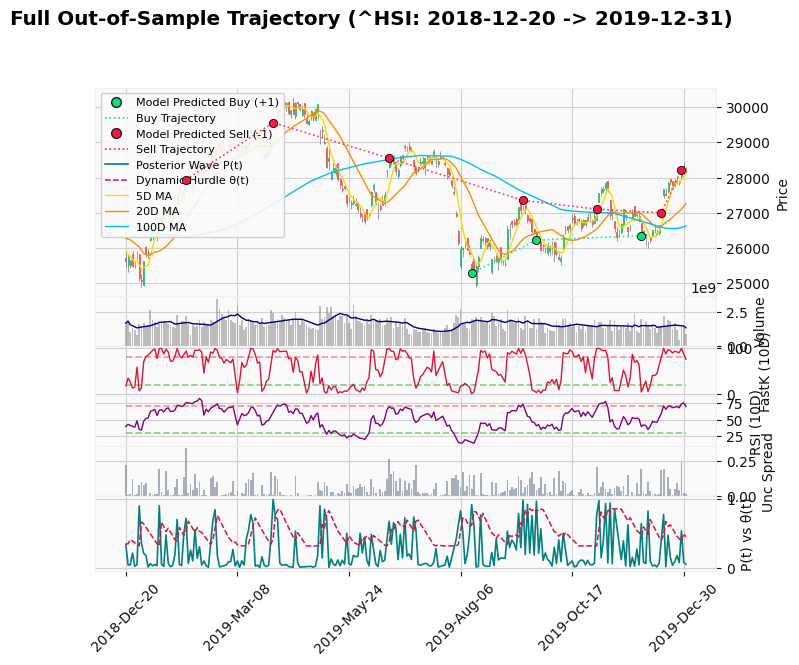

In [91]:
def plot_trajectory(
    clean_df,
    test_days,
    model,
    experts,
    X_test,
    engine,
    resample_freq='D',
    save_dir="/content/drive/MyDrive/backtest result"
):
    p_mean, unc_epistemic = extract_posterior(model, experts, X_test)

    test_slice = clean_df.iloc[-test_days:].copy()
    min_n = min(len(test_slice), len(p_mean))
    data = test_slice.iloc[-min_n:].copy()
    data.index = pd.to_datetime(data.index)

    p_sliced = p_mean[-min_n:]
    unc_sliced = unc_epistemic[-min_n:]

    signals, thetas = engine.classify(
        probs=p_sliced,
        uncs=unc_sliced,
        rsi_series=data['RSI_10_Ctr'].values,
        fastk_series=data['FastK_10_Ctr'].values,
        prc_dev_5d_series=data['Prc_Dev_5D'].values
    )

    data['P_Mean'] = p_sliced
    data['Theta_Dyn'] = thetas
    data['Uncertainty'] = unc_sliced
    data['Model_Signal'] = signals

    data['RSI_10_Orig'] = np.clip((data['RSI_10_Ctr'] + 0.5) * 100.0, 0.0, 100.0)
    data['FastK_10_Orig'] = np.clip((data['FastK_10_Ctr'] + 0.5) * 100.0, 0.0, 100.0)

    model_buys, model_sells = [], []
    for i in range(len(data)):
        curr_date = data.index[i]
        price = data['Close'].iloc[i]
        sig = data['Model_Signal'].iloc[i]

        if sig == 1:
            model_buys.append((curr_date, price))
        elif sig == -1:
            model_sells.append((curr_date, price))

    agg_dict = {
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum',
        'RSI_10_Orig': 'last', 'FastK_10_Orig': 'last', 'Uncertainty': 'last',
        'P_Mean': 'last', 'Theta_Dyn': 'last', 'Model_Signal': 'last'
    }
    for c in ['5D_MA', '20D_MA', '100D_MA']:
        if c in data.columns:
            agg_dict[c] = 'last'

    plot_data = data.resample(resample_freq).agg(agg_dict).dropna()
    plot_data['Vol_MA'] = plot_data['Volume'].rolling(window=10, min_periods=1).mean().fillna(0)

    plot_dates = plot_data.index.tolist()
    def get_x_idx(target_date):
        for idx, p_date in enumerate(plot_dates):
            if p_date >= target_date:
                return idx
        return len(plot_dates) - 1

    model_buy_coords = [(get_x_idx(d), p) for d, p in model_buys]
    model_sell_coords = [(get_x_idx(d), p) for d, p in model_sells]

    apds = []
    if '5D_MA' in plot_data.columns:
        apds.append(mpf.make_addplot(plot_data['5D_MA'], color='gold', panel=0, width=1.0))
    if '20D_MA' in plot_data.columns:
        apds.append(mpf.make_addplot(plot_data['20D_MA'], color='darkorange', panel=0, width=1.0))
    if '100D_MA' in plot_data.columns:
        apds.append(mpf.make_addplot(plot_data['100D_MA'], color='deepskyblue', panel=0, width=1.0))

    apds.extend([
        mpf.make_addplot(plot_data['Volume'], type='bar', color='gray', panel=1, alpha=0.5, ylabel='Volume'),
        mpf.make_addplot(plot_data['Vol_MA'], color='navy', panel=1, width=1.0),
        mpf.make_addplot(plot_data['FastK_10_Orig'], color='crimson', panel=2, ylabel='FastK (10D)', width=1.0),
        mpf.make_addplot([80.0] * len(plot_data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([20.0] * len(plot_data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(plot_data['RSI_10_Orig'], color='purple', panel=3, ylabel='RSI (10D)', width=1.0),
        mpf.make_addplot([70.0] * len(plot_data), color='red', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot([30.0] * len(plot_data), color='green', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot(plot_data['Uncertainty'], type='bar', panel=4, color='slategrey', ylabel='Unc Spread', alpha=0.6),
        mpf.make_addplot(plot_data['P_Mean'], color='teal', panel=5, ylabel='P(t) vs θ(t)', width=1.2),
        mpf.make_addplot(plot_data['Theta_Dyn'], color='crimson', linestyle='--', panel=5, width=1.1)
    ])

    full_start = data.index[0].strftime('%Y-%m-%d')
    full_end = data.index[-1].strftime('%Y-%m-%d')

    fig, axlist = mpf.plot(
        plot_data, type='candle', style='yahoo', addplot=apds,
        panel_ratios=(5, 1.2, 1.2, 1.2, 1.2, 1.8), figratio=(40, 32), figscale=1.2,
        title=f'Full Out-of-Sample Trajectory ({TARGET_TICKER}: {full_start} -> {full_end})', returnfig=True
    )

    ax_main = axlist[0]
    MARKER_SIZE = 35

    if model_buy_coords:
        bx, by = zip(*model_buy_coords)
        ax_main.plot(bx, by, color='#00E676', linestyle=':', linewidth=1.2, alpha=0.85, zorder=12)

    if model_sell_coords:
        sx, sy = zip(*model_sell_coords)
        ax_main.plot(sx, sy, color='#FF1744', linestyle=':', linewidth=1.2, alpha=0.85, zorder=12)

    for idx, price in model_buy_coords:
        ax_main.scatter(idx, price, color='#00E676', marker='o', s=MARKER_SIZE, edgecolors='black', linewidths=0.6, zorder=14)
    for idx, price in model_sell_coords:
        ax_main.scatter(idx, price, color='#FF1744', marker='o', s=MARKER_SIZE, edgecolors='black', linewidths=0.6, zorder=14)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', mfc='#00E676', mec='k', ms=7, label='Model Predicted Buy (+1)'),
        Line2D([0], [0], color='#00E676', lw=1.2, ls=':', label='Buy Trajectory'),
        Line2D([0], [0], marker='o', color='w', mfc='#FF1744', mec='k', ms=7, label='Model Predicted Sell (-1)'),
        Line2D([0], [0], color='#FF1744', lw=1.2, ls=':', label='Sell Trajectory'),
        Line2D([0], [0], color='teal', lw=1.2, label='Posterior Wave P(t)'),
        Line2D([0], [0], color='crimson', lw=1.1, ls='--', label='Dynamic Hurdle θ(t)')
    ]
    if '5D_MA' in plot_data.columns:
        legend_elements.append(Line2D([0], [0], color='gold', lw=1, label='5D MA'))
    if '20D_MA' in plot_data.columns:
        legend_elements.append(Line2D([0], [0], color='darkorange', lw=1, label='20D MA'))
    if '100D_MA' in plot_data.columns:
        legend_elements.append(Line2D([0], [0], color='deepskyblue', lw=1, label='100D MA'))

    ax_main.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.9)

    # Save to Drive using clean date bounds (matching checkpoint format)
    os.makedirs(save_dir, exist_ok=True)
    start_clean = data.index[0].strftime('%Y%m%d')
    end_clean = data.index[-1].strftime('%Y%m%d')
    save_path = os.path.join(save_dir, f"Trajectory_{TARGET_TICKER}_{start_clean}_{end_clean}.png")

    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"💾 Saved Trajectory Chart to: {save_path}")

    plt.show()

    return data


# --- SECTION 9 EXECUTION ---
test_data = plot_trajectory(
    clean_df=clean_df,
    test_days=TEST_DAYS_N,
    model=model,
    experts=experts,
    X_test=dataset['X_test'],
    engine=calibrated_engine,
    resample_freq='D'
)

## 10. Interactive Decision Boundary Dashboard & Client HTML5 Exporter

**What this cell does:**
* **In-Notebook:** Generates an `ipywidgets` dashboard with sliders for all 19 features, allowing you to visually explore the neural network's 2D decision manifolds in real-time[cite: 6].
* **HTML5 Export:** Averages the weights of the 100 SGLD experts and hardcodes the GRU mathematical forward pass into JavaScript[cite: 6]. It exports a standalone, 60 FPS HTML web app to Google Drive that clients can open in any browser to inspect the model's logic without needing Python or PyTorch[cite: 6].

In [92]:
def plot_dashboard(model, experts, scaler, feature_names, X_train, engine, time_steps=5):
    X_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_orig = scaler.inverse_transform(X_reshaped)
    medians = np.median(X_orig, axis=0)

    fastk_idx = feature_names.index('FastK_10_Ctr') if 'FastK_10_Ctr' in feature_names else 2
    rsi_idx = feature_names.index('RSI_10_Ctr') if 'RSI_10_Ctr' in feature_names else 1
    dev5_idx = feature_names.index('Prc_Dev_5D') if 'Prc_Dev_5D' in feature_names else 9

    dropdown_y = widgets.Dropdown(
        options=feature_names,
        value=feature_names[fastk_idx],
        description='Y-Axis:',
        style={'description_width': '60px'}
    )

    slider_widgets = {}
    for i, f_name in enumerate(feature_names):
        f_min = float(np.min(X_orig[:, i]))
        f_max = float(np.max(X_orig[:, i]))
        f_med = float(medians[i])

        slider_widgets[f_name] = widgets.FloatSlider(
            value=f_med,
            min=f_min,
            max=f_max,
            step=(f_max - f_min) / 100.0 if f_max != f_min else 0.01,
            description=f_name,
            continuous_update=False,
            style={'description_width': '150px'},
            layout={'width': '380px'}
        )

    def update_view(y_feat, **kwargs):
        idx_y = feature_names.index(y_feat)
        current_state = medians.copy()

        for f_name, slider_val in kwargs.items():
            if f_name in feature_names:
                current_state[feature_names.index(f_name)] = slider_val

        dot_y = current_state[idx_y]
        x_features = [f for f in feature_names if f != y_feat]
        num_plots = len(x_features)

        cols = 4
        rows = math.ceil(num_plots / cols)

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.0))
        axes = axes.flatten()

        grid_res = 25
        y_min, y_max = np.percentile(X_orig[:, idx_y], [1, 99])
        y_range = np.linspace(y_min, y_max, grid_res)

        total_points = num_plots * (grid_res ** 2)
        all_grid_points = np.zeros((total_points, len(feature_names)))
        plot_metadata = []

        for i, x_feat in enumerate(x_features):
            idx_x = feature_names.index(x_feat)
            x_min, x_max = np.percentile(X_orig[:, idx_x], [1, 99])
            x_range = np.linspace(x_min, x_max, grid_res)

            XX, YY = np.meshgrid(x_range, y_range)
            grid_points = np.tile(current_state, (grid_res ** 2, 1))
            grid_points[:, idx_x] = XX.ravel()
            grid_points[:, idx_y] = YY.ravel()

            start_idx = i * (grid_res ** 2)
            end_idx = (i + 1) * (grid_res ** 2)
            all_grid_points[start_idx:end_idx] = grid_points
            plot_metadata.append((x_feat, idx_x, x_min, x_max))

        f_dim = len(feature_names)
        grid_seqs = np.tile(all_grid_points[:, np.newaxis, :], (1, time_steps, 1))
        grid_scaled = scaler.transform(grid_seqs.reshape(-1, f_dim)).reshape(total_points, time_steps, f_dim)
        t_grid = torch.tensor(grid_scaled, dtype=torch.float32, device=DEVICE)

        model.eval()
        with torch.no_grad():
            scores = []
            for s_dict in experts:
                model.load_state_dict(s_dict)
                logits, _ = model(t_grid)
                scores.append(logits)
            scores_tensor = torch.stack(scores, dim=0)
            p_all = torch.sigmoid(scores_tensor).mean(dim=0).cpu().numpy()

        cmap_colors = ['#FF5252', '#E0E0E0', '#4CAF50']
        cmap = mcolors.ListedColormap(cmap_colors)
        bounds = [-1.5, -0.5, 0.5, 1.5]
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        for i, (x_feat, idx_x, x_min, x_max) in enumerate(plot_metadata):
            start_idx = i * (grid_res ** 2)
            end_idx = (i + 1) * (grid_res ** 2)

            p_grid = p_all[start_idx:end_idx]
            grid_slice = all_grid_points[start_idx:end_idx]

            is_active = p_grid >= engine.p_floor
            rsi_g = grid_slice[:, rsi_idx]
            fastk_g = grid_slice[:, fastk_idx]
            dev5_g = grid_slice[:, dev5_idx]

            is_trough = (fastk_g < 0.0) & (rsi_g < 0.0)
            is_peak   = (fastk_g > 0.0) & (rsi_g > 0.0)

            neutral_g = ~is_trough & ~is_peak
            is_trough = is_trough | (neutral_g & (dev5_g < 0.0))
            is_peak   = is_peak | (neutral_g & (dev5_g > 0.0))

            z_signals = np.zeros(grid_res ** 2, dtype=int)
            z_signals[is_active & is_trough] = 1
            z_signals[is_active & is_peak & ~is_trough] = -1

            Z_mat = z_signals.reshape((grid_res, grid_res))
            dot_x = current_state[idx_x]

            ax = axes[i]
            im = ax.imshow(
                Z_mat,
                origin='lower',
                aspect='auto',
                extent=[x_min, x_max, y_min, y_max],
                cmap=cmap,
                norm=norm
            )

            ax.scatter(dot_x, dot_y, color='cyan', edgecolors='black', s=100, marker='*', zorder=10)
            ax.set_title(f"{x_feat} vs {y_feat}", fontsize=9, fontweight='bold')
            ax.set_xlabel(x_feat, fontsize=8)
            ax.set_ylabel(y_feat, fontsize=8)
            ax.tick_params(axis='both', labelsize=8)

        for j in range(num_plots, len(axes)):
            fig.delaxes(axes[j])

        cbar_ax = fig.add_axes([1.01, 0.15, 0.015, 0.7])
        cbar = fig.colorbar(im, cax=cbar_ax, ticks=[-1, 0, 1])
        cbar.ax.set_yticklabels(['Sell (-1)', 'Hold (0)', 'Buy (+1)'])

        plt.suptitle(f"Decision Manifold (Static Y = {y_feat})", fontsize=15, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    ui = widgets.interactive_output(update_view, {'y_feat': dropdown_y, **slider_widgets})
    controls_box = widgets.VBox([
        widgets.HBox([dropdown_y]),
        widgets.Label(f"Global Live Input Sliders ({len(feature_names)} Total):"),
        widgets.VBox(list(slider_widgets.values()), layout={'max_height': '240px', 'overflow_y': 'scroll'})
    ])

    display(controls_box, ui)

def export_standalone_html_dashboard(
    model,
    experts,
    scaler,
    feature_names,
    X_train,
    engine,
    time_steps=5,
    save_dir="/content/drive/MyDrive/backtest result"
):
    """
    Exports a zero-dependency, ultra-smooth (60 FPS) standalone HTML5/JS dashboard
    with the exact GRU + LayerNorm forward pass embedded for client inspection.
    """
    os.makedirs(save_dir, exist_ok=True)

    X_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_orig = scaler.inverse_transform(X_reshaped)
    medians = np.median(X_orig, axis=0).tolist()
    mins = np.percentile(X_orig, 1, axis=0).tolist()
    maxs = np.percentile(X_orig, 99, axis=0).tolist()

    model.eval()
    with torch.no_grad():
        W_proj = model.input_projector[0].weight.detach().cpu().numpy().tolist()
        b_proj = model.input_projector[0].bias.detach().cpu().numpy().tolist()

        W_ih = np.mean([s['gru.weight_ih_l0'].cpu().numpy() for s in experts], axis=0).tolist()
        W_hh = np.mean([s['gru.weight_hh_l0'].cpu().numpy() for s in experts], axis=0).tolist()
        b_ih = np.mean([s['gru.bias_ih_l0'].cpu().numpy() for s in experts], axis=0).tolist()
        b_hh = np.mean([s['gru.bias_hh_l0'].cpu().numpy() for s in experts], axis=0).tolist()

        ln_gamma = model.hidden_norm.weight.detach().cpu().numpy().tolist()
        ln_beta = model.hidden_norm.bias.detach().cpu().numpy().tolist()

        W_fc = np.mean([s['fc.weight'].cpu().numpy() for s in experts], axis=0).tolist()
        b_fc = np.mean([s['fc.bias'].cpu().numpy() for s in experts], axis=0).tolist()

    scaler_mean = scaler.mean_.tolist()
    scaler_scale = scaler.scale_.tolist()

    engine_meta = {
        'p_floor': float(engine.p_floor),
        'alpha': float(engine.alpha) if hasattr(engine, 'alpha') else 0.08,
        'k_p': float(engine.k_p) if hasattr(engine, 'k_p') else 1.8
    }

    payload = {
        'features': feature_names,
        'time_steps': time_steps,
        'mins': mins,
        'maxs': maxs,
        'medians': medians,
        'scaler_mean': scaler_mean,
        'scaler_scale': scaler_scale,
        'weights': {
            'W_proj': W_proj, 'b_proj': b_proj,
            'W_ih': W_ih, 'W_hh': W_hh,
            'b_ih': b_ih, 'b_hh': b_hh,
            'ln_gamma': ln_gamma, 'ln_beta': ln_beta,
            'W_fc': W_fc, 'b_fc': b_fc
        },
        'engine': engine_meta
    }

    html_content = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Turning Point Decision Manifold ({TARGET_TICKER})</title>
<style>
  body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif; background: #0f172a; color: #f8fafc; margin: 0; padding: 20px; display: flex; height: 100vh; box-sizing: border-box; overflow: hidden; }}
  #sidebar {{ width: 340px; background: #1e293b; padding: 18px; border-radius: 12px; overflow-y: auto; display: flex; flex-direction: column; gap: 12px; box-shadow: 0 4px 6px -1px rgba(0,0,0,0.5); }}
  #main {{ flex: 1; margin-left: 20px; overflow-y: auto; padding-right: 10px; }}
  .grid {{ display: grid; grid-template-columns: repeat(auto-fill, minmax(240px, 1fr)); gap: 14px; }}
  .card {{ background: #1e293b; border-radius: 8px; padding: 10px; text-align: center; border: 1px solid #334155; }}
  canvas {{ width: 100%; height: 180px; image-rendering: pixelated; border-radius: 4px; background: #000; cursor: crosshair; }}
  .slider-group {{ display: flex; flex-direction: column; gap: 4px; }}
  .slider-label {{ display: flex; justify-content: space-between; font-size: 11px; color: #94a3b8; font-weight: 600; }}
  input[type=range] {{ width: 100%; accent-color: #38bdf8; cursor: pointer; }}
  select {{ background: #334155; color: #fff; border: 1px solid #475569; padding: 8px; border-radius: 6px; font-weight: bold; width: 100%; cursor: pointer; }}
  .badge {{ font-size: 10px; padding: 2px 6px; border-radius: 4px; font-weight: bold; }}
  .b-buy {{ background: #059669; color: #fff; }}
  .b-sell {{ background: #dc2626; color: #fff; }}
  .b-hold {{ background: #475569; color: #fff; }}
  h2 {{ margin: 0 0 10px 0; font-size: 16px; color: #38bdf8; border-bottom: 1px solid #334155; padding-bottom: 8px; }}
</style>
</head>
<body>

<div id="sidebar">
  <h2>Control Manifold</h2>
  <div>
    <label style="font-size: 11px; color: #94a3b8; font-weight: bold;">Y-AXIS FIXED VARIABLE</label>
    <select id="ySelect"></select>
  </div>
  <div style="display: flex; gap: 6px; font-size: 11px; justify-content: center; margin: 4px 0;">
    <span class="badge b-buy">Buy (+1)</span>
    <span class="badge b-hold">Hold (0)</span>
    <span class="badge b-sell">Sell (-1)</span>
  </div>
  <h2>Feature Input Sliders</h2>
  <div id="sliders" style="display: flex; flex-direction: column; gap: 10px;"></div>
</div>

<div id="main">
  <div class="grid" id="grid"></div>
</div>

<script>
const DATA = {json.dumps(payload)};
const RES = 20;
let currentValues = [...DATA.medians];
let yIdx = DATA.features.indexOf("FastK_10_Ctr") !== -1 ? DATA.features.indexOf("FastK_10_Ctr") : 2;

const ySelect = document.getElementById("ySelect");
DATA.features.forEach((f, i) => {{
  const opt = document.createElement("option");
  opt.value = i;
  opt.innerText = f;
  if(i === yIdx) opt.selected = true;
  ySelect.appendChild(opt);
}});

ySelect.onchange = (e) => {{
  yIdx = parseInt(e.target.value);
  buildCanvases();
  renderAll();
}};

const slidersDiv = document.getElementById("sliders");
DATA.features.forEach((f, i) => {{
  const grp = document.createElement("div");
  grp.className = "slider-group";
  grp.innerHTML = `
    <div class="slider-label"><span>${{f}}</span><span id="val_${{i}}">${{DATA.medians[i].toFixed(3)}}</span></div>
    <input type="range" id="sl_${{i}}" min="${{DATA.mins[i]}}" max="${{DATA.maxs[i]}}" step="${{(DATA.maxs[i] - DATA.mins[i]) / 100}}" value="${{DATA.medians[i]}}">
  `;
  slidersDiv.appendChild(grp);

  const sl = grp.querySelector("input");
  sl.oninput = (e) => {{
    currentValues[i] = parseFloat(e.target.value);
    document.getElementById(`val_${{i}}`).innerText = currentValues[i].toFixed(3);
    renderAll();
  }};
}});

function sigmoid(z) {{ return 1.0 / (1.0 + Math.exp(-z)); }}
function tanh(z) {{ return Math.tanh(z); }}
function leakyRelu(x) {{ return x > 0 ? x : 0.05 * x; }}

// Exact PyTorch Forward Pass in JavaScript: Linear -> LeakyReLU -> GRU -> LayerNorm -> Linear
function evaluatePoint(featVec) {{
  const norm = featVec.map((v, i) => (v - DATA.scaler_mean[i]) / DATA.scaler_scale[i]);
  const proj = [];
  for (let i = 0; i < 12; i++) {{
    let sum = DATA.weights.b_proj[i];
    for (let j = 0; j < norm.length; j++) sum += norm[j] * DATA.weights.W_proj[i][j];
    proj.push(leakyRelu(sum));
  }}

  let h = new Array(8).fill(0.0);
  const T = DATA.time_steps || 5;

  for (let step = 0; step < T; step++) {{
    let r_gate = new Array(8), z_gate = new Array(8), n_gate = new Array(8);
    for (let i = 0; i < 8; i++) {{
      let r_val = DATA.weights.b_ih[i] + DATA.weights.b_hh[i];
      let z_val = DATA.weights.b_ih[i + 8] + DATA.weights.b_hh[i + 8];
      let n_val = DATA.weights.b_ih[i + 16];
      let n_h = DATA.weights.b_hh[i + 16];

      for (let j = 0; j < 12; j++) {{
        r_val += DATA.weights.W_ih[i][j] * proj[j];
        z_val += DATA.weights.W_ih[i + 8][j] * proj[j];
        n_val += DATA.weights.W_ih[i + 16][j] * proj[j];
      }}
      for (let j = 0; j < 8; j++) {{
        r_val += DATA.weights.W_hh[i][j] * h[j];
        z_val += DATA.weights.W_hh[i + 8][j] * h[j];
        n_h += DATA.weights.W_hh[i + 16][j] * h[j];
      }}
      r_gate[i] = sigmoid(r_val);
      z_gate[i] = sigmoid(z_val);
      n_gate[i] = tanh(n_val + r_gate[i] * n_h);
    }}
    for (let i = 0; i < 8; i++) {{
      h[i] = (1.0 - z_gate[i]) * n_gate[i] + z_gate[i] * h[i];
    }}
  }}

  // LayerNorm(8)
  let mean = h.reduce((a, b) => a + b, 0) / 8.0;
  let variance = h.reduce((a, b) => a + Math.pow(b - mean, 2), 0) / 8.0;
  let h_norm = h.map((v, i) => ((v - mean) / Math.sqrt(variance + 1e-5)) * DATA.weights.ln_gamma[i] + DATA.weights.ln_beta[i]);

  // Linear Head
  let score = DATA.weights.b_fc[0];
  for (let i = 0; i < 8; i++) score += h_norm[i] * DATA.weights.W_fc[0][i];
  return sigmoid(score);
}}

function classifyState(prob, rsi, fastk, dev5) {{
  if (prob < DATA.engine.p_floor) return 0;
  const isTrough = (fastk < 0 && rsi < 0) || (dev5 < 0);
  const isPeak = (fastk > 0 && rsi > 0) || (dev5 > 0);
  if (isTrough) return 1;
  if (isPeak) return -1;
  return 0;
}}

const gridDiv = document.getElementById("grid");
let canvases = [];

function buildCanvases() {{
  gridDiv.innerHTML = "";
  canvases = [];
  DATA.features.forEach((f, i) => {{
    if (i === yIdx) return;
    const card = document.createElement("div");
    card.className = "card";
    card.innerHTML = `<div style="font-size: 12px; font-weight: bold; margin-bottom: 6px; color: #38bdf8;">${{f}} vs ${{DATA.features[yIdx]}}</div><canvas id="c_${{i}}" width="${{RES}}" height="${{RES}}"></canvas>`;
    gridDiv.appendChild(card);
    canvases.push({{ idx: i, canvas: card.querySelector("canvas") }});
  }});
}}

function renderAll() {{
  const rsiIdx = DATA.features.indexOf("RSI_10_Ctr");
  const fastkIdx = DATA.features.indexOf("FastK_10_Ctr");
  const dev5Idx = DATA.features.indexOf("Prc_Dev_5D");

  canvases.forEach(({{ idx, canvas }}) => {{
    const ctx = canvas.getContext("2d");
    const imgData = ctx.createImageData(RES, RES);
    const xMin = DATA.mins[idx], xMax = DATA.maxs[idx];
    const yMin = DATA.mins[yIdx], yMax = DATA.maxs[yIdx];

    let pVec = [...currentValues];
    for (let r = 0; r < RES; r++) {{
      const yVal = yMin + (r / (RES - 1)) * (yMax - yMin);
      pVec[yIdx] = yVal;
      for (let c = 0; c < RES; c++) {{
        const xVal = xMin + (c / (RES - 1)) * (xMax - xMin);
        pVec[idx] = xVal;

        const prob = evaluatePoint(pVec);
        const sig = classifyState(prob, pVec[rsiIdx], pVec[fastkIdx], pVec[dev5Idx]);

        const pxIdx = ((RES - 1 - r) * RES + c) * 4;
        if (sig === 1) {{
          imgData.data[pxIdx] = 5; imgData.data[pxIdx+1] = 150; imgData.data[pxIdx+2] = 105; imgData.data[pxIdx+3] = 255;
        }} else if (sig === -1) {{
          imgData.data[pxIdx] = 220; imgData.data[pxIdx+1] = 38; imgData.data[pxIdx+2] = 38; imgData.data[pxIdx+3] = 255;
        }} else {{
          imgData.data[pxIdx] = 51; imgData.data[pxIdx+1] = 65; imgData.data[pxIdx+2] = 85; imgData.data[pxIdx+3] = 255;
        }}
      }}
    }}
    ctx.putImageData(imgData, 0, 0);
  }});
}}

buildCanvases();
renderAll();
</script>
</body>
</html>"""

    start_clean = START_DATE.replace('-', '')
    end_clean = END_DATE.replace('-', '')
    save_path = os.path.join(save_dir, f"Manifold_App_{TARGET_TICKER}_{start_clean}_{end_clean}.html")

    with open(save_path, "w") as f:
        f.write(html_content)

    print(f"🚀 Client-Ready Interactive App Exported to Drive:\n • Path: {save_path}")
    return save_path


plot_dashboard(
    model=model,
    experts=experts,
    scaler=dataset['scaler'],
    feature_names=pipeline.feature_columns,
    X_train=dataset['X_train'],
    engine=calibrated_engine,
    time_steps=TIME_STEPS
)

export_standalone_html_dashboard(
    model=model,
    experts=experts,
    scaler=dataset['scaler'],
    feature_names=pipeline.feature_columns,
    X_train=dataset['X_train'],
    engine=calibrated_engine
)

Output()

🚀 Client-Ready Interactive App Exported to Drive:
 • Path: /content/drive/MyDrive/backtest result/Manifold_App_^HSI_20100101_20200101.html


'/content/drive/MyDrive/backtest result/Manifold_App_^HSI_20100101_20200101.html'

## 11. Zero-Lookahead Staged Pyramiding Backtest Engine & QuantStats Teardown

**What this cell does:**
* Executes a highly realistic backtest by enforcing **Next-Bar Open** fills, ensuring signals generated at the Close of bar $t$ are executed at the Open of $t+1$ to prevent lookahead bias[cite: 6].
* Implements a **Volatility-Gated Pyramiding System**: Capital is deployed in staggered tranches (e.g., 15%, 25%, 35%) only after consecutive calm periods. If the model detects a probability spike ($\ge 20\%$), the deployment timer pauses[cite: 6].
* Deducts a $0.50\%$ friction fee per transaction[cite: 6].
* Plots the strategy's equity curve against a Buy & Hold benchmark, exports the chart to Drive, and runs a comprehensive institutional `QuantStats` performance audit[cite: 6].

💾 Saved Backtest 7-Panel Chart to: /content/drive/MyDrive/backtest result/Backtest_^HSI_20181220_20191231.png


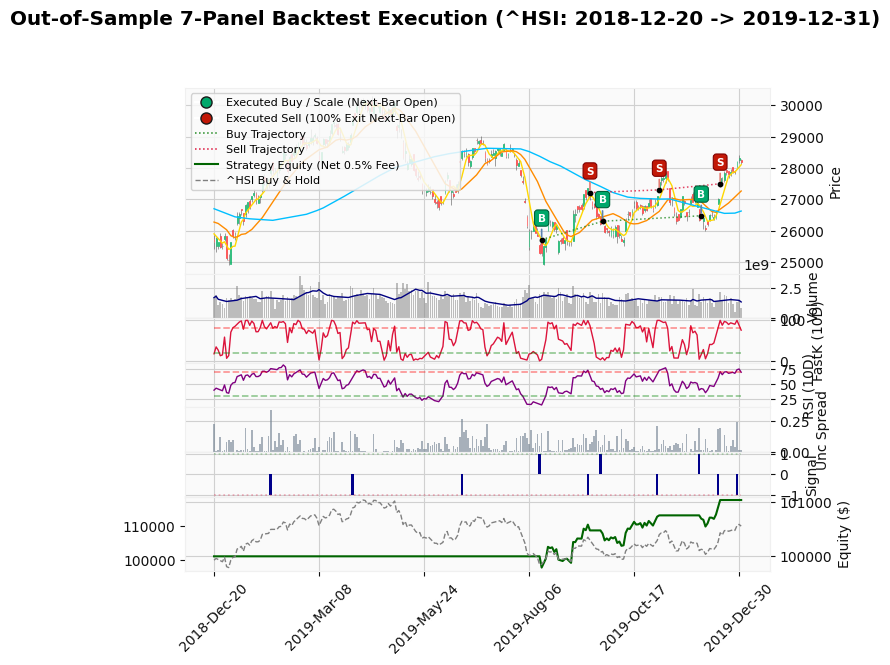


📊 QUANTSTATS INSTITUTIONAL PERFORMANCE AUDIT (NET OF 0.5% TRANSACTION FEE)
 • Total Realized Turnover Fees Paid: $306.47



Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  2.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2019-08-14   2019-08-14
End Period                 2019-12-31   2019-12-31
Risk-Free Rate             2.0%         2.0%
Time in Market             100.0%       65.0%

Cumulative Return          11.5%        1.04%
CAGR﹪                     33.09%       2.75%

Sharpe                     1.76         0.6
Prob. Sharpe Ratio         83.78%       89.18%
Smart Sharpe               1.66         0.56
Sortino                    2.88         1.01
Smart Sortino              2.72         0.95
Sortino/√2                 2.03         0.71
Smart Sortino/√2           1.92         0.67
Omega                      1.36         1.13

Max Drawdown               -6.41%       -0.39%
Max DD Date                2019-12-04   2019-10

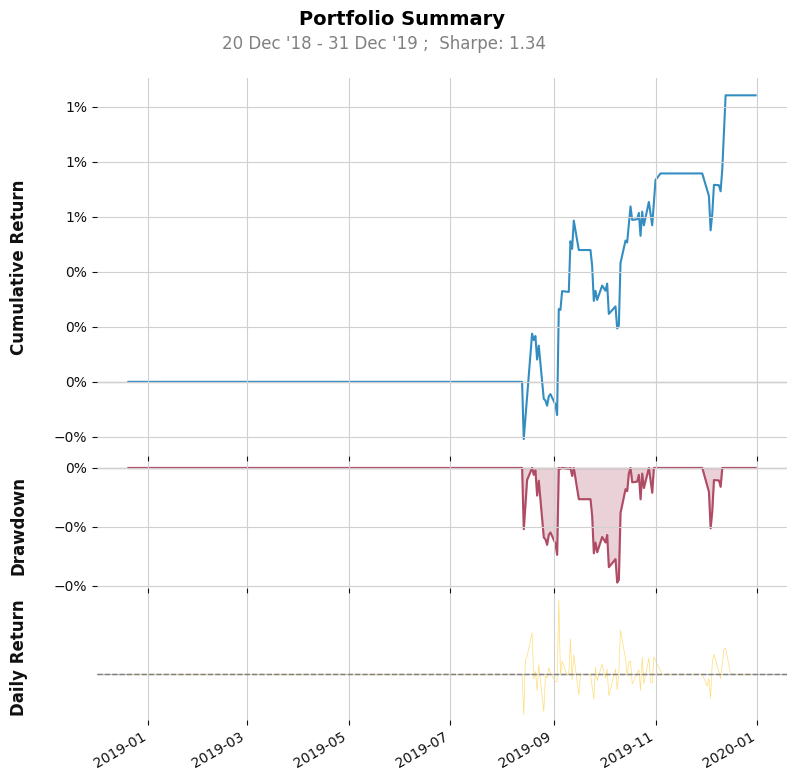

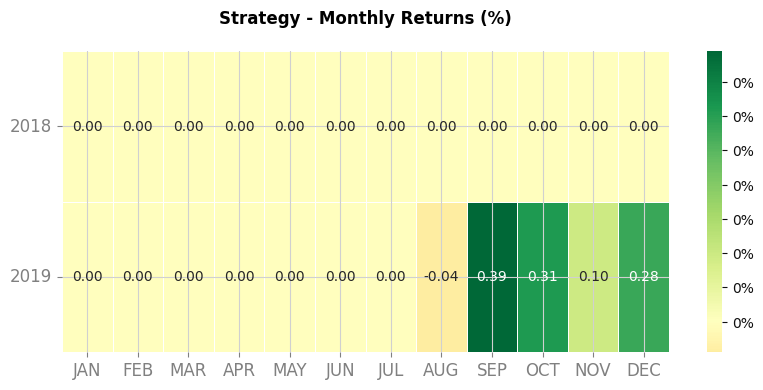

In [94]:
def run_staged_backtest(
    df,
    initial_capital=100000.0,
    fee_rate=0.005,                               # 0.50% transaction turnover fee
    scaling_interval=10,                          # 10-Day scaling pacing
    prob_reset_k=0.10,                            # 20% Probability spike reset threshold
    tranche_schedule=(0.05, 0.15, 0.35, 0.45)     # Sizing tier schedule (15% -> 25% -> 35% -> 25%)
):
    df_bt = df.copy()
    n = len(df_bt)

    close_prices = df_bt['Close'].values
    open_prices = df_bt['Open'].values
    signals = df_bt['Model_Signal'].values
    probs = df_bt['P_Mean'].values
    dates = df_bt.index

    cash = initial_capital
    shares = 0.0

    days_since_deploy = 0
    scale_stage = 0
    max_stages = len(tranche_schedule)

    equity = np.zeros(n, dtype=np.float64)
    exposure = np.zeros(n, dtype=np.float64)

    executed_buys = []
    executed_sells = []
    total_fees_paid = 0.0

    # Order action flags determined at t, executed at t+1
    pending_action = None  # None, 'SELL', 'BUY_INITIAL', 'BUY_SCALE'

    for t in range(n):
        # 1. Execute Pending Orders from t-1 at Current Bar's Open (Realistic Execution)
        if pending_action is not None:
            fill_price = open_prices[t]

            if pending_action == 'SELL' and shares > 1e-5:
                gross_proceeds = shares * fill_price
                fee = gross_proceeds * fee_rate
                net_proceeds = gross_proceeds - fee

                cash += net_proceeds
                shares = 0.0
                total_fees_paid += fee
                executed_sells.append((dates[t], fill_price))

                scale_stage = 0
                days_since_deploy = 0

            elif pending_action in ('BUY_INITIAL', 'BUY_SCALE'):
                current_port_val = cash + shares * fill_price
                tier_idx = min(scale_stage - 1, max_stages - 1)
                target_spend = min(cash, current_port_val * tranche_schedule[tier_idx])

                if target_spend > 50.0:
                    effective_spend = target_spend / (1.0 + fee_rate)
                    fee = target_spend - effective_spend
                    bought_shares = effective_spend / fill_price

                    shares += bought_shares
                    cash -= target_spend
                    total_fees_paid += fee
                    executed_buys.append((dates[t], fill_price))

            pending_action = None

        # 2. Evaluate Signals and Conditions at End of Bar t (Using Close[t])
        sig = signals[t]
        p_val = probs[t]

        if sig == -1 and shares > 1e-5:
            pending_action = 'SELL'

        elif sig == 1:
            scale_stage = 1
            days_since_deploy = 0
            pending_action = 'BUY_INITIAL'

        elif shares > 1e-5:
            # Model Volatility / Epistemic Spike: Reset day counter
            if p_val >= prob_reset_k:
                days_since_deploy = 0

            # 10 Consecutive Calm Days Elapsed: Queue next tranche
            elif days_since_deploy >= scaling_interval and scale_stage < max_stages:
                scale_stage += 1
                days_since_deploy = 0
                pending_action = 'BUY_SCALE'

            days_since_deploy += 1

        # 3. Mark to Market at Close[t]
        port_val = cash + shares * close_prices[t]
        equity[t] = port_val
        exposure[t] = (shares * close_prices[t]) / port_val if port_val > 0 else 0.0

    df_bt['Strategy'] = equity
    df_bt['Benchmark'] = initial_capital * (close_prices / close_prices[0])
    df_bt['Exposure'] = exposure

    return df_bt, executed_buys, executed_sells, total_fees_paid


def plot_7panel_backtest(
    data,
    executed_buys,
    executed_sells,
    title,
    resample_freq='D',
    save_dir="/content/drive/MyDrive/backtest result"
):
    agg_dict = {
        'Open': 'first', 'High': 'max', 'Low': 'min', 'Close': 'last', 'Volume': 'sum',
        'RSI_10_Orig': 'last', 'FastK_10_Orig': 'last', 'Uncertainty': 'last',
        'Model_Signal': 'last', 'Strategy': 'last', 'Benchmark': 'last'
    }
    for ma_col in ['5D_MA', '20D_MA', '100D_MA']:
        if ma_col in data.columns:
            agg_dict[ma_col] = 'last'

    plot_data = data.resample(resample_freq).agg(agg_dict).dropna()
    plot_data['Vol_MA'] = plot_data['Volume'].rolling(window=10, min_periods=1).mean()

    plot_dates = plot_data.index.tolist()
    def get_x_idx(target_date):
        for idx, p_date in enumerate(plot_dates):
            if p_date >= target_date:
                return idx
        return len(plot_dates) - 1

    buy_coords = [(get_x_idx(d), p) for d, p in executed_buys]
    sell_coords = [(get_x_idx(d), p) for d, p in executed_sells]

    apds = []
    if '5D_MA' in plot_data.columns:
        apds.append(mpf.make_addplot(plot_data['5D_MA'], color='gold', panel=0, width=1.0))
    if '20D_MA' in plot_data.columns:
        apds.append(mpf.make_addplot(plot_data['20D_MA'], color='darkorange', panel=0, width=1.0))
    if '100D_MA' in plot_data.columns:
        apds.append(mpf.make_addplot(plot_data['100D_MA'], color='deepskyblue', panel=0, width=1.0))

    apds.extend([
        mpf.make_addplot(plot_data['Volume'], type='bar', color='gray', panel=1, alpha=0.5, ylabel='Volume'),
        mpf.make_addplot(plot_data['Vol_MA'], color='navy', panel=1, width=1.0),
        mpf.make_addplot(plot_data['FastK_10_Orig'], color='crimson', panel=2, ylabel='FastK (10D)', width=1.0),
        mpf.make_addplot([80.0] * len(plot_data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([20.0] * len(plot_data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(plot_data['RSI_10_Orig'], color='purple', panel=3, ylabel='RSI (10D)', width=1.0),
        mpf.make_addplot([70.0] * len(plot_data), color='red', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot([30.0] * len(plot_data), color='green', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot(plot_data['Uncertainty'], type='bar', panel=4, color='slategrey', ylabel='Unc Spread', alpha=0.6),
        mpf.make_addplot(plot_data['Model_Signal'], type='bar', panel=5, color='darkblue', ylabel='Signal', width=1.2),
        mpf.make_addplot([1.0] * len(plot_data), color='forestgreen', linestyle=':', panel=5, alpha=0.3),
        mpf.make_addplot([-1.0] * len(plot_data), color='crimson', linestyle=':', panel=5, alpha=0.3),
        mpf.make_addplot(plot_data['Strategy'], panel=6, color='darkgreen', ylabel='Equity ($)', width=1.5),
        mpf.make_addplot(plot_data['Benchmark'], panel=6, color='gray', linestyle='--', width=1.0)
    ])

    fig, axlist = mpf.plot(
        plot_data, type='candle', style='yahoo', addplot=apds,
        panel_ratios=(5, 1.2, 1.2, 1.2, 1.2, 1.2, 2.0), figratio=(40, 34), figscale=1.2,
        title=title, returnfig=True
    )

    ax_signal = axlist[5]
    ax_signal.set_yticks([-1, 0, 1])
    ax_signal.set_yticklabels(['Sell (-1)', 'Hold (0)', 'Buy (+1)'], rotation=0, fontsize=8)

    ax_main = axlist[0]
    bbox_buy  = dict(boxstyle="round,pad=0.3", fc="#00A86B", ec="#006039", lw=0.8)
    bbox_sell = dict(boxstyle="round,pad=0.3", fc="#C21807", ec="#800000", lw=0.8)
    arrow_buy  = dict(arrowstyle="-", color="#5B84B1", lw=1.2)
    arrow_sell = dict(arrowstyle="-", color="#E67C73", lw=1.2)

    for idx, price in buy_coords:
        ax_main.scatter(idx, price, color='black', s=10, zorder=11)
        ax_main.annotate('B', xy=(idx, price), xytext=(0, 12), textcoords="offset points",
                         ha="center", va="bottom", bbox=bbox_buy, arrowprops=arrow_buy,
                         fontsize=7.5, fontweight='bold', color='white', zorder=12)

    for idx, price in sell_coords:
        ax_main.scatter(idx, price, color='black', s=10, zorder=11)
        ax_main.annotate('S', xy=(idx, price), xytext=(0, 12), textcoords="offset points",
                         ha="center", va="bottom", bbox=bbox_sell, arrowprops=arrow_sell,
                         fontsize=7.5, fontweight='bold', color='white', zorder=12)

    if buy_coords:
        bx, by = zip(*buy_coords)
        ax_main.plot(bx, by, color='forestgreen', linestyle=':', linewidth=1.1, alpha=0.8, zorder=7)
    if sell_coords:
        sx, sy = zip(*sell_coords)
        ax_main.plot(sx, sy, color='crimson', linestyle=':', linewidth=1.1, alpha=0.8, zorder=7)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', mfc='#00A86B', mec='k', ms=8, label='Executed Buy / Scale (Next-Bar Open)'),
        Line2D([0], [0], marker='o', color='w', mfc='#C21807', mec='k', ms=8, label='Executed Sell (100% Exit Next-Bar Open)'),
        Line2D([0], [0], color='forestgreen', lw=1.1, ls=':', label='Buy Trajectory'),
        Line2D([0], [0], color='crimson', lw=1.1, ls=':', label='Sell Trajectory'),
        Line2D([0], [0], color='darkgreen', lw=1.5, label='Strategy Equity (Net 0.5% Fee)'),
        Line2D([0], [0], color='gray', lw=1.0, ls='--', label=f'{TARGET_TICKER} Buy & Hold')
    ]
    ax_main.legend(handles=legend_elements, loc='upper left', fontsize=8, framealpha=0.85)

    # Save to Drive using backtest range dates
    os.makedirs(save_dir, exist_ok=True)
    start_clean = data.index[0].strftime('%Y%m%d')
    end_clean = data.index[-1].strftime('%Y%m%d')
    save_path = os.path.join(save_dir, f"Backtest_{TARGET_TICKER}_{start_clean}_{end_clean}.png")

    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"💾 Saved Backtest 7-Panel Chart to: {save_path}")

    plt.show()


# --- SECTION 11 EXECUTION ---
backtest_df, exec_buys, exec_sells, total_friction_paid = run_staged_backtest(
    df=test_data,
    initial_capital=100000.0,
    fee_rate=0.005,
    scaling_interval=20,                          # 10 days scaling interval
    prob_reset_k=0.05,                            # 20% model probability reset threshold
    tranche_schedule=(0.05, 0.15, 0.35, 0.45)     # Progressive size scaling tiers
)

start_date_str = backtest_df.index[0].strftime('%Y-%m-%d')
end_date_str = backtest_df.index[-1].strftime('%Y-%m-%d')
plot_7panel_backtest(
    data=backtest_df,
    executed_buys=exec_buys,
    executed_sells=exec_sells,
    title=f'Out-of-Sample 7-Panel Backtest Execution ({TARGET_TICKER}: {start_date_str} -> {end_date_str})',
    resample_freq='D'
)

strat_returns = backtest_df['Strategy'].pct_change().dropna()
bench_returns = backtest_df['Benchmark'].pct_change().dropna()

strat_returns.index = pd.to_datetime(strat_returns.index)
bench_returns.index = pd.to_datetime(bench_returns.index)

# Safe timezone check for QuantStats
if strat_returns.index.tz is not None:
    strat_returns.index = strat_returns.index.tz_localize(None)
if bench_returns.index.tz is not None:
    bench_returns.index = bench_returns.index.tz_localize(None)

print('\n' + '=' * 85)
print(f'📊 QUANTSTATS INSTITUTIONAL PERFORMANCE AUDIT (NET OF 0.5% TRANSACTION FEE)')
print(f' • Total Realized Turnover Fees Paid: ${total_friction_paid:,.2f}')
print('=' * 85)

qs.reports.metrics(
    returns=strat_returns,
    benchmark=bench_returns,
    rf=0.02,
    mode='full',
    display=True
)

print('\n' + '=' * 85)
print('📈 QUANTSTATS VISUAL PERFORMANCE & RISK BREAKDOWN')
print('=' * 85)

qs.reports.plots(returns=strat_returns, benchmark=bench_returns, mode='basic')